# Practical session 2 - Practise with classic libraries

Students (pair):
- [Henry Fernandes--Strag]([link](https://github.com/hfstrag))
- [Alexandre Torres--Leguet]([link](https://github.com/alxndrTL))

```
conda create --name=lab2 --file=requirement.txt
conda activate lab2
# do not forget to deactivate the environment if needed
# you can remove the environment once you are done
conda env remove --name=lab2
```

**Useful references for this lab**:

[1] `numpy`: [lecture notes (1.4.1-1.4.2)](https://scipy-lectures.org/intro/numpy/index.html) and [documentation](https://numpy.org/doc/stable/)

[2] `pandas`: [documentation](https://pandas.pydata.org/docs/getting_started/index.html), [quick tutorial](https://pandas.pydata.org/pandas-docs/version/0.15/10min.html)

[3] `matplotlib`: [lecture notes (1.5)](https://scipy-lectures.org/intro/matplotlib/index.html) and [documentation](https://matplotlib.org/)

[4] `h5py`: [quick start guide](http://docs.h5py.org/en/stable/quick.html#quick)

## <a name="content">Contents</a>
- [Exercise 1: Computing basic statistics](#ex1)
- [Exercise 2: Random variables and histograms](#ex2)
- [Exercise 3: Discrete isotropic total variation](#ex3)
---

In [1]:
%load_ext autoreload
%autoreload 2


---
## <a name="ex1">Exercise 1: Random variables and histograms</a>

In this exercise, we are interested in generating samples from the Gamma distribution $\mathcal{G}(\alpha,\beta)$, of probability density function (pdf)

\begin{equation}
    p(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} \exp(-\beta x) \mathbb{1}_{\mathbb{R}_+^*}(x),
\end{equation}

and displaying their histogram. In the following, we consider $(\alpha, \beta) = (9, 2)$.

1\. Set the random seed to a fixed value for reproducibility, and biefly check your instruction works as intended.
> Hint: you may take a look at the following pages: [random module](https://numpy.org/doc/stable/reference/random/index.html?highlight=random#module-numpy.random), [random generator](https://numpy.org/doc/stable/reference/random/generator.html).

**Answer**:

In [2]:
import numpy as np
import h5py
np.random.seed(42)

#here we can check that the random generation of a random int always gives the same result
np.random.randint(0,10)


6

2\. Generate $\approx 10^5$ samples in a vector. Save the vector in a file, `samples.hdf5` or `samples.npy`.
> Warning / hint: 
> - take a careful look at the [documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.gamma.html?highlight=gamma#numpy.random.gamma) (multiple conventions exist for the definition of the pdf underlying the distribution...);
> - to save data in a `npy` file, take a look at the example reported in the [Numpy documentation](https://numpy.org/doc/stable/reference/generated/numpy.save.html);
> - to save data in a `.h5` file, take a quick look at the [documentation here](https://docs.h5py.org/en/stable/quick.html#quick).

**Answer**:

In [3]:
alpha, beta = 9, 2
X = np.random.gamma(shape = alpha, scale = 1/beta, size = (10**5, 1))
#par identification des paramètres de la doc de np.random.gamma

#Enregistrement en .npy
np.save("./gamma.npy", X)

# Enregistrement en .h5
with h5py.File("./gamma.h5", "w") as f:
    f.create_dataset("X", data=X)
    f.attrs["alpha"] = alpha
    f.attrs["beta"] = beta

#conservation des paramètres
with h5py.File("./gamma.h5", "r") as f:
    X = f["X"][:]
    alpha = f.attrs["alpha"]
    beta = f.attrs["beta"]

3\. Estimate an histogram of this distribution for a well chosen set of bins, and display it.
> Warnings: 
> - make sure the [histogram](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html?highlight=hist#matplotlib.pyplot.hist) corresponds to a probability density function (pdf);
> - do not forget to include a proper title with names for the axes.

**Answer**:

Text(0.5, 0, 'value taken by the law')

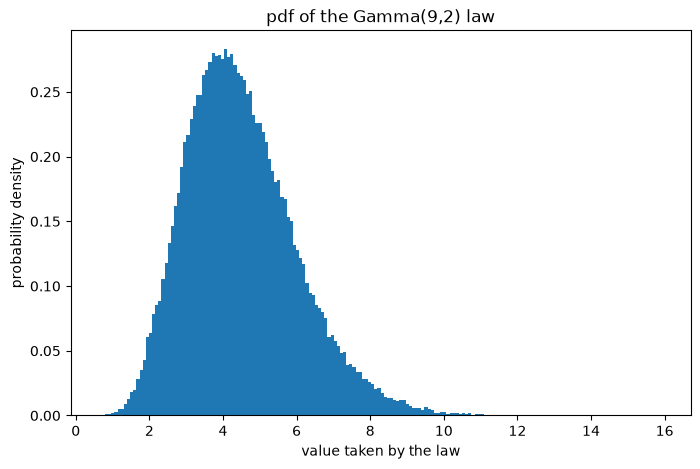

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(x = X, bins = "fd", density = True)
ax.set_title("pdf of the Gamma(9,2) law")
ax.set_ylabel("probability density")
ax.set_xlabel("value taken by the law")

4\. Overlay the probability density function on the histogram and compare these in a few words. Save the resulting picture in `.png` format.
> Hint: 
> - take a look at the `scipy` [documentation](https://docs.scipy.org/doc/scipy/reference/stats.html) to avoid implementing the pdf from scratch;
> - return the bins in which the histogram is computed, and evaluate the pdf on those points.

**Answer**:

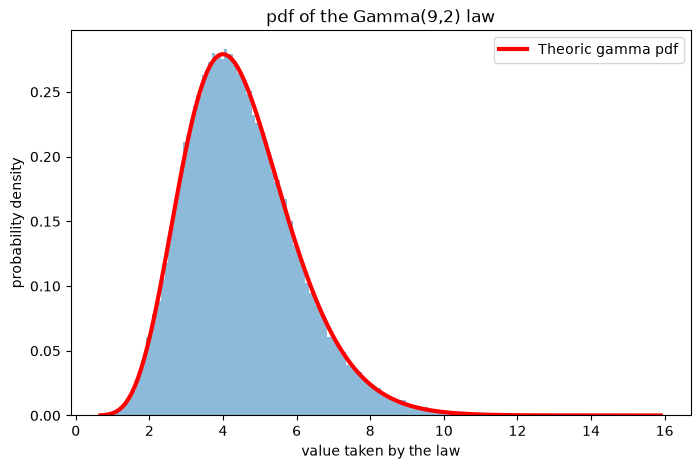

In [5]:

from scipy.stats import gamma

fig, ax = plt.subplots(figsize=(8, 5))

hist, bins, _ = ax.hist(x = X, bins = "fd", density = True, alpha = 0.5)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax.set_title("pdf of the Gamma(9,2) law")
ax.set_ylabel("probability density")
ax.set_xlabel("value taken by the law")

pdf = gamma.pdf(bin_centers, a=9, scale=1/2)

ax.plot(
    bin_centers,
    pdf,
    'r-',
    lw=3,
    label='Theoric gamma pdf'
)

ax.legend()
plt.savefig("./gamma.png")
plt.show()


---
## <a name="ex2">Exercise 2: Basic statistics with `pandas`</a>

In this second exercise, we focus on computing basic statistics, and applying linear regression to a small data set. These data are gathered in the following table, which gives the infant mortality (`X`) and the gross national product per inhabitant (`Y`) of 12 european countries :

| `X` | 190 | 128 | 180 | 212 | 56 | 192 | 68 | 98 | 110 | 197 | 181 | 233 |
|-----|-----|-----|-----|----|-----|----|----|-----|-----|-----|-----|-----|
| `Y` |  24 |  28 |  24 | 19 |  37 | 22 | 34 |  25 |  36 |  24 |  20 |  18 |

1\. For `X `and `Y`, compute the median, mean, variance and standard deviation. The data points have already been entered into a `.csv` file stored in `data/data.csv`.
> Hint: 
> - you can directly use `pandas` to load the data into a `DataFrame` ([`pd.read_csv`](https://pandas.pydata.org/docs/reference/frame.html));
> - take a look at the built-in operations available for `DataFrame` objects ([documentation](https://pandas.pydata.org/docs/reference/frame.html));
> - to display a `DataFrame` `f`:
> ```python 
> from IPython.display import display
> display(df)
> ```
> - sort the `DataFrame` with respect to the value of `X` (see [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values)) This will be useful for question 3.

**Answer**:

In [6]:
from IPython.display import display
import pandas as pd
df = pd.read_csv("./data/data.csv")

df = df.sort_values(by = ["X"])
display(df)
stats = pd.DataFrame({
    "Médiane": df.median(),
    "Moyenne": df.mean(),
    "Variance": df.var(),
    "Écart-type": df.std()
})

print(stats)
#ou bien :

stats_2 = df.describe()
print(stats_2)


,X,Y
4,56,37
6,68,34
7,98,25
8,110,36
1,128,28
2,180,24
10,181,20
0,190,24
5,192,22
9,197,24


   Médiane     Moyenne     Variance  Écart-type
X    180.5  153.750000  3486.022727   59.042550
Y     24.0   25.916667    42.446970    6.515134
               X          Y
count   12.00000  12.000000
mean   153.75000  25.916667
std     59.04255   6.515134
min     56.00000  18.000000
25%    107.00000  21.500000
50%    180.50000  24.000000
75%    193.25000  29.500000
max    233.00000  37.000000


2\. Give the equation of the regression line of `Y` as a function of `X`.
> Hint: 
> - take a look at the functionalities available in `numpy` (e.g., `np.polyfit` and `np.polyval`);
> - if needed, note that you can retrieve the data from the resulting `pandas` `DataFrame` with the `to_numpy()` method.

**Answer**:

In [7]:
Df = df.to_numpy()
X = Df[:, 0]
Y = Df[:, 1]
coefficients = np.polyfit(X, Y, deg = 1)
print(coefficients)

#ou bien :

a, b = np.polyfit(df["X"], df["Y"], deg=1)
signe = "+" if b >= 0 else "-"
print(f"Y = {a:.2f}X {signe} {abs(b):.2f}")

[-0.09816475 41.0094968 ]
Y = -0.10X + 41.01


3\. Display the cloud of points and the regression line $Y = f(X)$ on the same figure. Save the figure in `.png` format.

**Answer**:

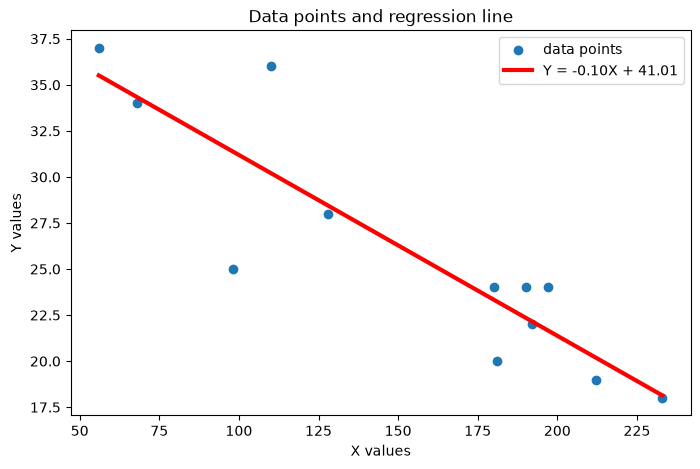

In [8]:
fig, ax = plt.subplots(figsize = (8,5))

X = df["X"]
Y = df["Y"]
ax.scatter(
    X,
    Y,
    label='data points'
)
ax.set_title("Data points and regression line")

ax.plot(
    X,
    a*X + b,
    'r-',
    lw=3,
    label=f"Y = {a:.2f}X + {b:.2f}"
)

ax.legend()
ax.set_ylabel("Y values")
ax.set_xlabel("X values")
plt.savefig("./regression_line")
plt.show()

---
## <a name="ex3">Exercise 3: Discrete isotropic total variation</a>

This exercise is devoted to the computation of the discrete isotropic total variation (TV) of an input matrix $\mathbf{X} = [\mathbf{x}_n]_{1 \leq n \leq N} \in\mathbb{C}^{M \times N}$, which is particularly useful in Bayesian inference (e.g., for inverse problems) to promote piece-wise smooth solutions. The TV is defined as

\begin{equation*}
    \text{TV}(\mathbf{X}) = \Vert D(\mathbf{X}) \Vert_{1,2} = \sum_{m=1}^M \sum_{n=1}^N \sqrt{[\mathbf{XD}_h]^2_{m,n} + [\mathbf{D}_v\mathbf{X}]^2_{m,n}},
\end{equation*}

where $[\mathbf{Z}]_{m,n}$ denotes the elements in position $(m,n)$ of the matrix $\mathbf{Z}$,

\begin{align*}
    D(X) &= (\mathbf{XD}_h, \mathbf{D}_v\mathbf{X}) \in \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \\
    %
    \mathbf{XD}_h &= [\mathbf{x}_2-\mathbf{x}_1, \dotsc, \mathbf{x}_N-\mathbf{x}_{N-1}, \mathbf{0}_M] \in \mathbb{C}^{M\times N} \\
    %
    \mathbf{D}_v\mathbf{X} &= [\tilde{\mathbf{x}}_2^T-\tilde{\mathbf{x}}^T_1, \dotsc, \tilde{\mathbf{x}}^T_M-\tilde{\mathbf{x}}^T_{M-1}, \mathbf{0}_N]^T \in \mathbb{C}^{M\times N},
\end{align*}

$\mathbf{x}_n \in \mathbb{C}^{M}$ is the $n$-th column of $\mathbf{X}$, and $\tilde{\mathbf{x}}_m \in \mathbb{C}^{1\times N}$ is the $m$-th row of $\mathbf{X}$. 
The linear operator $D: \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} $ is the discrete gradient operator. The adjoint of $D$, $D^*: \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N}$, is given by

\begin{align*}
    (\forall \mathbf{Y} = (\mathbf{Y}_h,\mathbf{Y}_v)), \quad D^*(\mathbf{Y}) &= \mathbf{Y}_h\mathbf{D}^*_h + \mathbf{D}^*_v\mathbf{Y}_v \\
    %
    \mathbf{Y}_h\mathbf{D}^*_h &= \big[-\mathbf{y}_{h,1},- [\mathbf{y}_{h,n}-\mathbf{y}_{h,n-1}]_{2 \leq n \leq N-1}, \mathbf{y}_{h, N-1} \big] \\
    %
    \mathbf{D}^*_v\mathbf{Y}_v &= \big[-\tilde{\mathbf{y}}_{v,1}^T,- [\tilde{\mathbf{y}}_{v,m}^T-\tilde{\mathbf{y}}^T_{v,m-1}]_{2 \leq m \leq M-1}, \tilde{\mathbf{y}}^T_{v, M-1} \big]^T
\end{align*}

where $\mathbf{y}_{h,n}$ is the $n$-th column of $\mathbf{Y}_h$, and $\tilde{\mathbf{y}}_{v,m}$ is the $m$-th row of $\mathbf{Y}_v$.

1\. Using `numpy`, implement a function `gradient2D` to compute the 2D discrete gradient operator $D$ applied to a matrix $\mathbf{X}\in\mathbb{C}^{M \times N}$ (no for loops!). Trigger an error message whenever the input array has more than 2 dimensions. If not clear from the implementation, add a few short comments to explain your code.

> Hint: 
> - to trigger an error, you can for instance use an `assert` statement, or raise an [exception (e.g., `AssertionError`)](https://docs.python.org/3/library/exceptions.html);
> - only a few operations are needed: computing vertical differences, horizontal differences, and possibly a concatenation of matrices into a single tensor (= n-dimensional array);
> - possibly useful functions: `np.diff`, `np.c_`, `np.r_` (or `np.concatenate`). 

**Answer**:

In [9]:
def gradient2D(X: np.array) -> np.array:
    # check that X is a 2D matrix
    if X.ndim >2 :
        raise ValueError("Input array must have at most 2 dimensions")

    X_D = np.column_stack((
        X[:, 1:] - X[:, :-1],
        np.zeros(X.shape[0])
    ))

    D_X = np.vstack((
        X[1:, :] - X[:-1, :],
        np.zeros(X.shape[1])
    ))

    return X_D, D_X

2\. Implement a unit-test to validate the behaviour of the `gradient2D` function. For instance, you can check the format of the output, and test the result when the function is evaluated on a constant matrix (for both a square and a non-square input matrix). Run the unit-test from the present Jupyter notebook.

**Answer**:

In [18]:
#the unit tests are imported from the tests/test_fn_lab2.py file
#runnning the tests :

!pytest -q tests/tests_fn_lab2.py


....                                                                     [100%]
4 passed in 0.13s


3\. Document the function `gradient2D` with an appropriate docstring (see Lab 1).

**Answer**:

In [ ]:
#docstring following the numpy format
def gradient2D(X: np.array) -> np.array:
    """
    Compute the discrete gradient of a 2D matrix along both axes.

    The derivative along each axis is approximated using forward finite
    differences (f[i+1] - f[i]). The last column (resp. last row) is set
    to zero to match the shape of the input.

    Parameters
    ----------
    X : np.ndarray
        Input 2D matrix of shape (M, N).

    Returns
    -------
    X_D : np.ndarray
        Horizontal gradient (along columns), of shape (M, N).

    D_X : np.ndarray
        Vertical gradient (along rows), of shape (M, N).

    Raises
    ------
    ValueError
        If X has more than 2 dimensions.

    Examples
    --------
    >>> X = np.array([[1, 2, 3],
    ...               [4, 5, 6]])
    >>> X_D, D_X = gradient2D(X)
    >>> X_D  # horizontal differences
    array([[1., 1., 0.],
           [1., 1., 0.]])
    >>> D_X  # vertical differences
    array([[3., 3., 3.],
           [0., 0., 0.]])
    """
    # check that X is a 2D matrix
    if X.ndim > 2:
        raise ValueError("Input array must have at most 2 dimensions")

    X_D = np.column_stack((
        X[:, 1:] - X[:, :-1],
        np.zeros(X.shape[0])
    ))

    D_X = np.vstack((
        X[1:, :] - X[:-1, :],
        np.zeros(X.shape[1])
    ))

    return X_D, D_X

4\. Using 1., define a function `tv` to compute $\text{TV}(\mathbf{X})$, $\mathbf{X}\in\mathbb{C}^{M \times N}$. Write a unit-test and document your function.

**Answer**:

In [23]:
def tv(X: np.array) -> float:
    """
    Compute the Total Variation (TV) of a 2D matrix.

    The total variation is defined as the sum of the gradient magnitudes
    over all pixels, where border differences are set to zero (see gradient2D).

    Parameters
    ----------
    X : np.ndarray
        Input 2D matrix of shape (M, N).

    Returns
    -------
    float
        Total variation of X (non-negative).

    Examples
    --------
    >>> tv(np.zeros((3, 3)))
    0.0
    >>> tv(np.ones((3, 3)))
    0.0
    >>> tv(np.array([[0, 1], [0, 1]]))
    2.0
    """

    X_D, D_X = gradient2D(X)
    return np.sum(np.sqrt(X_D**2 + D_X**2))

#unit test in tests/test_fn_lab2.py file

!pytest -q tests/tests_fn_lab2.py

...............                                                          [100%]
15 passed in 0.11s


5\. Implement a function `gradient2D_adjoint` to compute $D^*(\mathbf{Y})$, the adjoint of the 2D discrete gradient operator $D$ applied to $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$. Add a few short comments to explain your code whenever appropriate.

**Answer**:

In [ ]:
def gradient2D_adjoint(Y: np.array) -> np.array:
    """
    Compute the adjoint (negative divergence) of the 2D discrete gradient.

    Concretely, G* is the negative discrete divergence, computed via
    backward finite differences.

    Parameters
    ----------
    Y : np.ndarray
        Input array of shape (2, M, N), where Y[0] is the horizontal
        component and Y[1] is the vertical component.

    Returns
    -------
    np.ndarray
        Adjoint of the gradient applied to Y, of shape (M, N).

    Raises
    ------
    ValueError
        If Y does not have shape (2, M, N).

    Examples
    --------
    >>> Y = np.zeros((2, 3, 3))
    >>> gradient2D_adjoint(Y)
    array([[0., 0., 0.],
           [0., 0., 0.],
           [0., 0., 0.]])
    """
    if Y.ndim != 3 or Y.shape[0] != 2:
        raise ValueError("Y must have shape (2, M, N).")

    # Adjoint of the horizontal gradient
    Y_D = np.column_stack((
        -Y[0][:, 0],
        -(Y[0][:, 1:-1] - Y[0][:, :-2]),
        Y[0][:, -2]
    ))

    # Adjoint of the vertical gradient
    D_Y = np.vstack((
        -Y[1][0, :],
        -(Y[1][1:-1, :] - Y[1][:-2, :]),
        Y[1][-2, :]
    ))

    return Y_D + D_Y

6\. Implement a unit-test to validate `gradient2D_adjoint`, e.g., by checking the size of the output from the function and verifying that `gradient2D_adjoint` is adjoint to `gradient2D`, i.e., for any $\mathbf{X}\in\mathbb{C}^{M \times N}$ and $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$:

\begin{equation}
    \forall \mathbf{X} \in \mathbb{C}^{M \times N}, \mathbf{Y} = (\mathbf{Y}_h, \mathbf{Y}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \;
    %
    \langle D(\mathbf{X}), \mathbf{Y} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{X}, D^*(\mathbf{Y}) \rangle_{\mathbb{C}^{M \times N}}, 
\end{equation}

where 

\begin{align}
    &\forall \mathbf{U}, \mathbf{V} \in \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N}} = \text{Tr}(\mathbf{U}^T \mathbf{V}) = \sum_{m=1}^M \sum_{n=1}^N u_{m,n}^* v_{m,n}, \\
    &\forall \mathbf{U} = (\mathbf{U}_h, \mathbf{U}_v), \mathbf{V} = (\mathbf{V}_h, \mathbf{V}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{U}_h, \mathbf{V}_h \rangle_{\mathbb{C}^{M \times N}} + \langle \mathbf{U}_v, \mathbf{V}_v \rangle_{\mathbb{C}^{M \times N}}.
\end{align}

> Hint: to verify `gradient2D_adjoint` is the adjoint of `gradient2D`, evaluate the scalar products above for randomly drawn matrices. Set the random generator to a known state for reproducibility (see [Exercise 1](#ex1)).

> `np.conj` is useful.

**Answer**:

In [25]:
#unit test in tests/test_fn_lab2.py file

!pytest -q tests/tests_fn_lab2.py

......................                                                   [100%]
22 passed in 0.11s


[Bonus, **optional**]. Generalize the `gradient2D` to any number of dimensions ($\mathbf{X} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}$), i.e., by returning tensors obtained by computing differences along each of its dimensions.
> Hint: 
> - you may use a loops here, and/or list comprehension. Using slice objects (see [np.s_](https://numpy.org/doc/stable/reference/generated/numpy.s_.html?highlight=s_#numpy.s_) and [this page](https://stackoverflow.com/questions/24432209/python-index-an-array-using-the-colon-operator-in-an-arbitrary-dimension)) can be an interesting option.
>
> - the definition of the scalar product above can be extended to the case of tensors as follows:
\begin{equation}
    \mathbf{U}, \mathbf{V} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}} =  \sum_{n_1 = 1}^{N_1}  \sum_{n_2 = 1}^{N_2} \dotsc \sum_{n_p = 1}^{N_p} u_{n_1, n_2, \dotsc, n_p}^* v_{n_1, n_2, \dotsc, n_p}   
\end{equation}

**Answer**:

In [15]:
# your code

## Reference

```bibtex
@article{condat:hal-01309685,
  TITLE = {{Discrete Total Variation: New Definition and Minimization}},
  AUTHOR = {Condat, Laurent},
  URL = {https://hal.archives-ouvertes.fr/hal-01309685},
  JOURNAL = {{SIAM Journal on Imaging Sciences}},
  PUBLISHER = {{Society for Industrial and Applied Mathematics}},
  VOLUME = {10},
  NUMBER = {3},
  PAGES = {1258--1290},
  YEAR = {2017},
  MONTH = Aug,
  DOI = {10.1137/16M1075247},
  KEYWORDS = { variational image processing ; total variation ;  finite-difference schemes ;  coarea formula},
  PDF = {https://hal.archives-ouvertes.fr/hal-01309685v3/file/Condat-newTV.pdf},
  HAL_ID = {hal-01309685},
  HAL_VERSION = {v3},
}
```
